In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import openpyxl
import datetime

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("dataset/Customer-Purchase-History.xlsx")
df.head(10)

,CustomerID,Product,PurchaseDate,Quantity,UnitPrice,CustomerName,ProductCategory,PaymentMethod,ReviewRating,TotalPrice
0,C5361,Phone,2024-03-05,8,618.83,Customer C5361,Office Supplies,Cash,1,4950.64
1,C6231,Laptop,2025-06-21,7,366.22,Customer C6231,Electronics,Debit Card,3,2563.54
2,C7704,Chair,2023-06-25,5,634.51,Customer C7704,Office Supplies,Credit Card,4,3172.55
3,C2923,Printer,2023-09-30,3,508.63,Customer C2923,Office Supplies,Gift Card,1,1525.89
4,C4847,Monitor,2023-04-03,4,452.06,Customer C4847,Electronics,Credit Card,2,1808.24
5,C7317,Chair,2023-04-11,3,209.79,Customer C7317,Office Supplies,Gift Card,1,629.37
6,C5076,Desk,2024-06-19,3,88.74,Customer C5076,Office Supplies,Debit Card,3,266.22
7,C5181,Chair,2023-08-16,8,273.92,Customer C5181,Furniture,Credit Card,2,2191.36
8,C9564,Monitor,2023-02-11,6,718.79,Customer C9564,Electronics,Gift Card,3,4312.74
9,C7521,Tablet,2025-06-14,7,100.37,Customer C7521,Office Supplies,Debit Card,4,702.59


In [23]:
df.columns

Index(['CustomerID', 'Product', 'PurchaseDate', 'Quantity', 'UnitPrice',
       'CustomerName', 'ProductCategory', 'PaymentMethod', 'ReviewRating',
       'TotalPrice'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       1800 non-null   object        
 1   Product          1800 non-null   object        
 2   PurchaseDate     1800 non-null   datetime64[ns]
 3   Quantity         1800 non-null   int64         
 4   UnitPrice        1800 non-null   float64       
 5   CustomerName     1800 non-null   object        
 6   ProductCategory  1800 non-null   object        
 7   PaymentMethod    1800 non-null   object        
 8   ReviewRating     1800 non-null   int64         
 9   TotalPrice       1800 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 140.8+ KB


In [14]:
df["Product"].value_counts()

Product
Laptop     280
Tablet     278
Desk       256
Monitor    254
Chair      253
Phone      246
Printer    233
Name: count, dtype: int64

In [49]:
df["ProductCategory"].value_counts()

ProductCategory
Electronics        606
Office Supplies    597
Furniture          597
Name: count, dtype: int64

# Sales Performance & Revenue

##### 1- Which product categories and individual products are the primary drivers of revenue, and how concentrated is revenue among top-performing products?

<p><b>Strategic Value:</b> Identifies the products/categories that deserve greater inventory, marketing, and management attention while revealing dependency on a small number of products.</p>

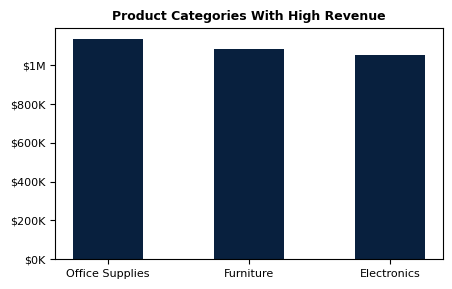

In [11]:
product_category = df.groupby(["ProductCategory"],as_index=False)["TotalPrice"].sum()
product_category = product_category.sort_values(by="TotalPrice",ascending=False).reset_index(drop=True)
# product_category["RevenueShare"] = (product_category["TotalPrice"] / np.sum(product_category["TotalPrice"]))*100

plt.figure(figsize=(5,3))
plt.bar(product_category["ProductCategory"],product_category["TotalPrice"],color="#08203E",width=0.5)
plt.title("Product Categories With High Revenue",fontsize=9,fontweight='bold')
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)
plt.gca().yaxis.set_major_formatter(FuncFormatter(
        lambda x, pos: (
            f'${x/1_000_000:g}M' if x >= 1_000_000
            else f'${x/1_000:,.0f}K'
        )
    )
)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.savefig('plots/Sales Performance & Revenue/Question 01/Product Categories With High Revenue.png')
plt.show()

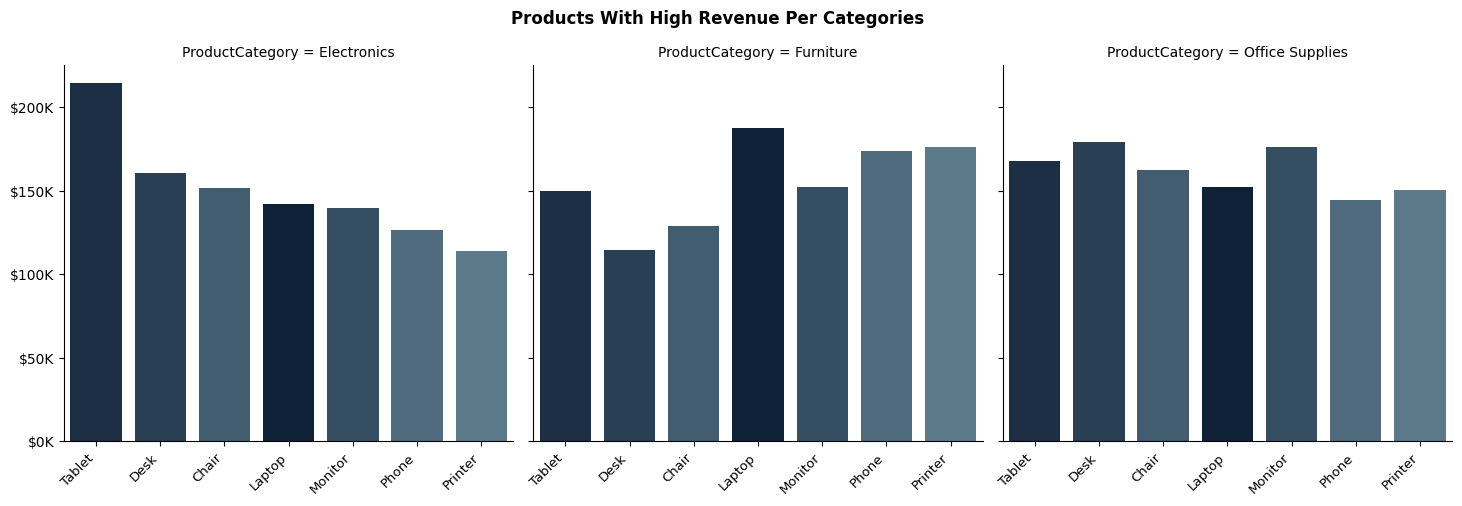

In [4]:
product = df.groupby(["ProductCategory","Product"], as_index=False)["TotalPrice"].sum()
product = product.sort_values(by=["ProductCategory","TotalPrice"], ascending=[True,False]).reset_index(drop=True)

colors = {
    "Laptop" : "#08203E",
    "Tablet" : "#152F4C",
    "Desk" : "#223F5A",
    "Monitor" : "#2F4E69",
    "Chair" : "#3B5D77",
    "Phone" : "#486D85",
    "Printer" : "#557C93"
}
ax = sns.catplot(data=product, kind="bar", x="Product",
                 y="TotalPrice", col="ProductCategory",
                 palette=colors)

for axis in ax.axes.flat:
    axis.yaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f'${x/1000:.0f}K')
    )

ax.set_xlabels("")
ax.set_ylabels("")
ax.set_xticklabels(fontsize=9.5, rotation=45, horizontalalignment='right')
ax.fig.subplots_adjust(top=0.87)
ax.fig.suptitle('Products With High Revenue Per Categories',fontsize=12,fontweight='bold')

plt.savefig('plots/Sales Performance & Revenue/Question 01/Products With High Revenue Per Categories.png')

plt.show()

##### 2- How has sales revenue and sales volume evolved over time, and are there statistically meaningful periods of growth or decline?

<p><b>Strategic Value:</b> Reveals business growth patterns, seasonality, demand changes, and periods requiring investigation or intervention.</p>

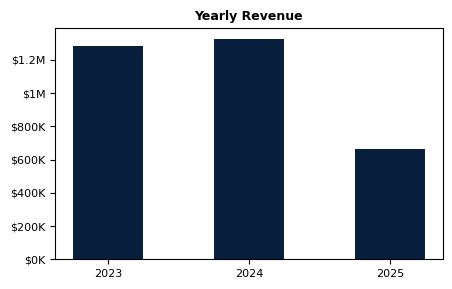

In [12]:
yearly_data = df.copy()

yearly_data["PurchaseDate"] = pd.to_datetime(yearly_data["PurchaseDate"])
yearly_data["PurchaseDate(Year)"] = yearly_data["PurchaseDate"].dt.strftime("%Y")

yearly_revenue = yearly_data.groupby(["PurchaseDate(Year)"],as_index=False)["TotalPrice"].sum()

plt.figure(figsize=(5,3))
plt.bar(yearly_revenue["PurchaseDate(Year)"],yearly_revenue["TotalPrice"],color="#08203E",width=0.5)
plt.title("Yearly Revenue",fontsize=9,fontweight='bold')
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)
plt.gca().yaxis.set_major_formatter(FuncFormatter(
        lambda x, pos: (
            f'${x/1_000_000:g}M' if x >= 1_000_000
            else f'${x/1_000:,.0f}K'
        )
    )
)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.savefig('plots/Sales Performance & Revenue/Question 02/Yearly Revenue.png')

plt.show()

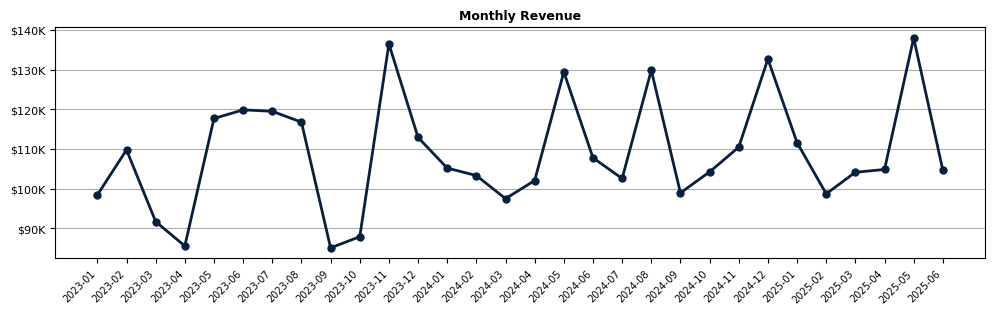

In [83]:
monthly_data = df.copy()

monthly_data["PurchaseDate"] = pd.to_datetime(monthly_data["PurchaseDate"])
monthly_data["PurchaseDate(Year-Month)"] = monthly_data["PurchaseDate"].dt.strftime("%Y-%m")

monthly_revenue = monthly_data.groupby(["PurchaseDate(Year-Month)"],as_index=False)["TotalPrice"].sum()

plt.figure(figsize=(12,3))
plt.plot(monthly_revenue["PurchaseDate(Year-Month)"],monthly_revenue["TotalPrice"],
         color="#08203E",
        marker='o',lw=2,ms=5)

plt.gca().yaxis.set_major_formatter(FuncFormatter(
        lambda x, pos: (
            f'${x/1_000_000:g}M' if x >= 1_000_000
            else f'${x/1_000:,.0f}K'
        )
    )
)
plt.xticks(fontsize=7,rotation=45,horizontalalignment='right')
plt.yticks(fontsize=8)
plt.grid(axis='y')
plt.title("Monthly Revenue",fontsize=9,fontweight='bold')

plt.savefig('plots/Sales Performance & Revenue/Question 02/Monthly Revenue.png',bbox_inches="tight")

plt.show()

##### 3- Which products generate high revenue but low sales volume, and which generate high volume but relatively low revenue?

<p><b>Strategic Value:</b> Helps distinguish premium/high-value products from volume-driven products and supports differentiated pricing and inventory strategies.</p>

In [96]:
df.columns

Index(['CustomerID', 'Product', 'PurchaseDate', 'Quantity', 'UnitPrice',
       'CustomerName', 'ProductCategory', 'PaymentMethod', 'ReviewRating',
       'TotalPrice'],
      dtype='object')

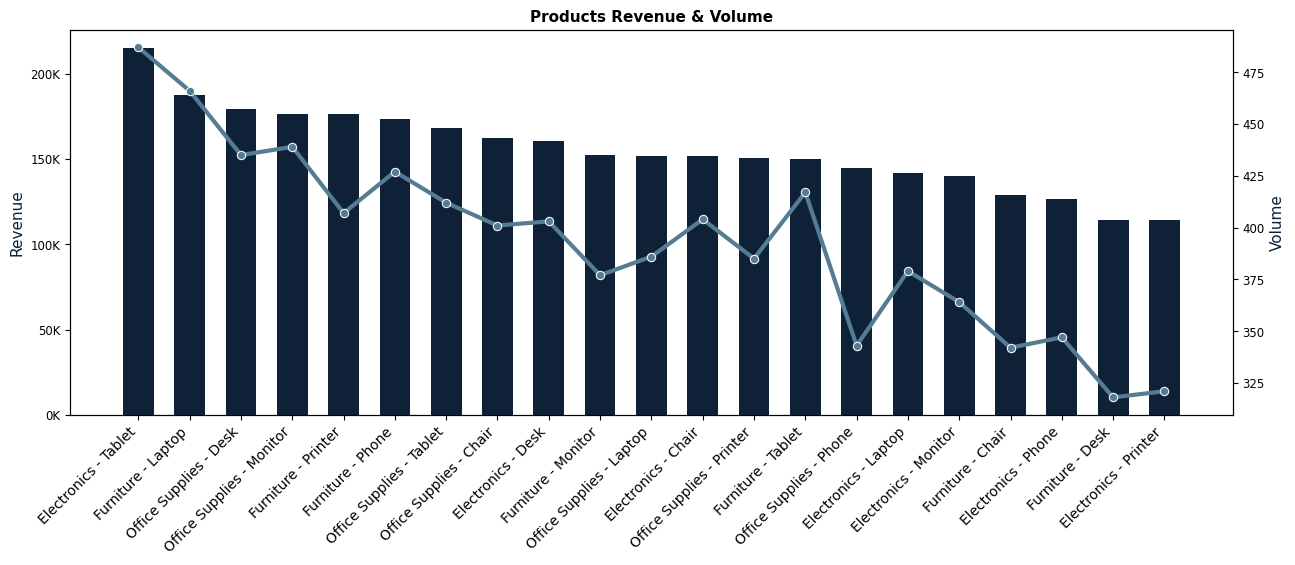

In [130]:
revenue = df.groupby(["ProductCategory","Product"],as_index=False)[["Quantity","TotalPrice"]].sum()
revenue["ProductLabel"] = revenue["ProductCategory"] + " - " + revenue["Product"]
revenue["ASP"] = revenue["TotalPrice"] / revenue["Quantity"]
revenue = revenue.sort_values(by="TotalPrice",ascending=False).reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(15,5))
sns.barplot(data=revenue, x="ProductLabel",y="TotalPrice",ax=ax1,color="#08203E",width=0.6)
ax1.tick_params(axis='x',labelsize=10,rotation=45)
plt.setp(
    ax1.get_xticklabels(),
    ha='right'
)
ax1.tick_params(axis='y',labelsize=8.5)
ax1.set_xlabel("")
ax1.set_ylabel("Revenue",fontsize=11,color="#08203E")
ax1.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: (
            f'{x/1_000_000:g}M' if x >= 1_000_000
            else f'{x/1_000:,.0f}K'
        )
    )
)

ax2=ax1.twinx()
sns.lineplot(data=revenue, x="ProductLabel",y="Quantity",ax=ax2,color="#557C93",marker='o',linewidth=3)
ax2.set_ylabel("Volume",fontsize=11,color="#08203E")
ax2.tick_params(axis='y',labelsize=8.5)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))

plt.title("Products Revenue & Volume",fontsize=11,fontweight='bold')

plt.savefig('plots/Sales Performance & Revenue/Question 03/Products Revenue & Volume.png',bbox_inches="tight")

plt.show()

In [132]:
# Sales Performance & Revenue

#Question 01
product_category.to_excel("export-data/Sales Performance & Revenue/Question 01/product_category_revenue.xlsx",index=False)
product.to_excel("export-data/Sales Performance & Revenue/Question 01/product_revenue.xlsx",index=False)

#Question 02
yearly_revenue.to_excel("export-data/Sales Performance & Revenue/Question 02/yearly_revenue.xlsx",index=False)
monthly_revenue.to_excel("export-data/Sales Performance & Revenue/Question 02/monthly_revenue.xlsx",index=False)

# Question 03
revenue.to_excel("export-data/Sales Performance & Revenue/Question 03/revenue.xlsx",index=False)